<a href="https://colab.research.google.com/github/alanagadelha/DeepLearning_AntarticaWork/blob/main/ICONANT_SCRM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd

csv_path = '/content/drive/MyDrive/Colab Notebooks/scrm_cdo_limpo.csv'
df = pd.read_csv(csv_path)
df.head()

# Mostra as 5 primeiras linhas
print(df.head())

# Verifica nomes das colunas
print(df.columns)


     2023-09-01 00:00:00     CLCL 98.48242 
0    2023-09-01 00:00:00     CLCM      100 
1    2023-09-01 00:00:00     CLCH      100 
2    2023-09-01 00:00:00     CLCT      100 
3    2023-09-01 00:00:00     ceil      344 
4   2023-09-01 00:00:00      lsm 0.3330383 
Index([' 2023-09-01 00:00:00     CLCL 98.48242 '], dtype='object')


In [ ]:
import pandas as pd

csv_path = '/content/drive/MyDrive/Colab Notebooks/scrm_cdo_limpo.csv'

# Lê o arquivo separando por espaços em branco
df = pd.read_csv(
    csv_path,
    delim_whitespace=True,
    names=["date", "time", "var", "value"],
    comment='#',
    engine='python'
)

# Remove linhas mal formatadas
df = df[df["date"].str.match(r"\d{4}-\d{2}-\d{2}")]

# Junta data e hora em um datetime completo
df["datetime"] = pd.to_datetime(df["date"] + " " + df["time"])

# Mantém apenas as colunas relevantes
df = df[["datetime", "var", "value"]]

# Converte para formato wide (cada variável vira uma coluna)
df_wide = df.pivot_table(index="datetime", columns="var", values="value")

# Salva no CSV
df_wide.to_csv('/content/drive/MyDrive/Colab Notebooks/scrm_cdo_wide.csv')

# Visualiza
print(df.head())


/tmp/ipython-input-3-4229470439.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


    datetime   var      value
0 2023-09-01  CLCL   98.48242
1 2023-09-01  CLCM  100.00000
2 2023-09-01  CLCH  100.00000
3 2023-09-01  CLCT  100.00000
4 2023-09-01  ceil  344.00000


In [ ]:
import pandas as pd

csv_path = '/content/drive/MyDrive/Colab Notebooks/scrm_cdo_limpo.csv'

# Lê o CSV separando pelos espaços em branco
df = pd.read_csv(
    csv_path,
    sep='\s+',
    names=["date", "time", "var", "value"],
    comment='#',
    engine='python'
)

# Remove linhas mal formatadas (sem datas válidas)
#df = df[df["date"].str.match(r"\d{4}-\d{2}-\d{2}")]

# Cria coluna datetime
df["datetime"] = pd.to_datetime(df["date"] + " " + df["time"])

# Reorganiza colunas
df = df[["datetime", "var", "value"]]

# Transforma para formato wide
df_wide = df.pivot_table(index="datetime", columns="var", values="value")

# Salva como CSV
df_wide.to_csv('/content/drive/MyDrive/Colab Notebooks/scrm_cdo_wide.csv')

print(df.head())



#df_wide = df.pivot_table(index="datetime", columns="var", values="value")
#print(df_wide.head())

    datetime   var      value
0 2023-09-01  CLCL   98.48242
1 2023-09-01  CLCM  100.00000
2 2023-09-01  CLCH  100.00000
3 2023-09-01  CLCT  100.00000
4 2023-09-01  ceil  344.00000


In [ ]:
display(df_wide.head())

var,10u,10v,2d,2r,2t,CAPE_CON,CIN_ML,CLCH,CLCL,CLCM,...,max_2t,max_i10fg,min_2t,prmsl,sde,sp,tp,utaua,vis,vtaua
datetime,,,,,,,,,,,,,,,,,,,,,
2023-09-01 00:00:00,5.548670,-9.573135,270.5673,88.32837,272.2492,4.171875,0.506226,100.000000,98.48242,100.00000,...,272.2500,14.57227,272.2453,97353.76,0.060547,97312.64,0.000000,0.000000,11526.0,0.000000
2023-09-01 03:00:00,0.118757,-7.611288,271.6519,93.40012,272.5814,14.589840,0.006226,99.455080,83.42578,51.86914,...,272.6562,15.14160,272.3141,97421.90,0.060547,97384.02,0.164062,0.002923,5650.0,-0.137821
2023-09-01 06:00:00,-1.182783,-5.712227,271.5755,92.94511,272.5716,6.482422,0.006226,3.642578,89.62500,41.87695,...,272.6875,10.30176,272.2828,97449.81,0.060547,97409.27,0.239258,-0.017993,5986.0,-0.090039
2023-09-01 09:00:00,-6.849104,3.863632,268.7796,93.48045,269.6761,24.392580,0.006226,37.130860,99.91406,100.00000,...,272.5938,10.54590,269.5181,97571.41,0.076172,97537.47,2.317383,-0.110038,310.5,0.063833
2023-09-01 12:00:00,-11.003030,2.527594,266.7294,85.87453,268.7293,6.896484,0.006226,0.349609,88.82031,36.82422,...,272.5938,15.16602,268.5078,97740.73,0.097656,97702.43,5.386719,-0.263396,4061.0,0.063954


In [ ]:
pip install metar

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.4/201.4 kB 9.8 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving SCRM.csv to SCRM.csv


In [ ]:
import pandas as pd

# Carrega o CSV enviado pela usuária
csv_path = "/content/SCRM.csv"
df = pd.read_csv(csv_path)

# Exibe as primeiras linhas e colunas disponíveis para inspecionar o conteúdo

df = df.rename(columns={
    'valid': 'time',
    'drct': 'wind_dir',
    'sknt': 'wind_knots',
    'wxcodes': 'Present_Weather_Code'
})
df.head(10)
df.tail(100)

,station,time,tmpc,dwpc,relh,wind_dir,wind_knots,alti,mslp,p01m,...,skyc2,skyc3,skyl1,skyl2,skyl3,Present_Weather_Code,peak_wind_gust,peak_wind_drct,peak_wind_time,metar
75640,SCRM,2025-07-08 17:00,0.0,-1.0,92.97,360.0,21.0,29.44,NaN,0.0,...,NaN,NaN,300.0,NaN,NaN,-SN FZFG,NaN,NaN,NaN,SCRM 081700Z 36021KT 0200 -SN FZFG OVC003 M00/...
75641,SCRM,2025-07-08 18:00,0.0,0.0,100.00,340.0,19.0,29.44,NaN,0.0,...,NaN,NaN,300.0,NaN,NaN,-SN FZFG,NaN,NaN,NaN,SCRM 081800Z 34019KT 0200 -SN FZFG OVC003 M00/...
75642,SCRM,2025-07-08 19:00,0.0,0.0,100.00,340.0,18.0,29.44,NaN,0.0,...,OVC,NaN,300.0,700.0,NaN,-SN BR,NaN,NaN,NaN,SCRM 081900Z 34018KT 1000 -SN BR BKN003 OVC007...
75643,SCRM,2025-07-08 20:00,0.0,0.0,100.00,340.0,16.0,29.47,NaN,0.0,...,OVC,NaN,200.0,500.0,NaN,FZFG,NaN,NaN,NaN,SCRM 082000Z 34016KT 0600 FZFG BKN002 OVC005 M...
75644,SCRM,2025-07-08 21:00,0.0,0.0,100.00,350.0,11.0,29.47,NaN,0.0,...,NaN,NaN,300.0,NaN,NaN,FZFG,NaN,NaN,NaN,SCRM 082100Z 35011KT 0600 FZFG OVC003 M00/M00 ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75735,SCRM,2025-07-14 19:00,-2.0,-5.0,79.91,240.0,14.0,29.68,NaN,0.0,...,NaN,NaN,2000.0,NaN,NaN,NaN,NaN,NaN,NaN,SCRM 141900Z 24014KT 9999 BKN020 M02/M05 Q1005...
75736,SCRM,2025-07-14 20:00,-2.0,-5.0,79.91,240.0,18.0,29.68,NaN,0.0,...,NaN,NaN,2200.0,NaN,NaN,NaN,NaN,NaN,NaN,SCRM 142000Z 24018KT 9999 BKN022 M02/M05 Q1005...
75737,SCRM,2025-07-14 21:00,-2.0,-5.0,79.91,240.0,16.0,29.71,NaN,0.0,...,NaN,NaN,2600.0,NaN,NaN,NaN,NaN,NaN,NaN,SCRM 142100Z 24016KT 9999 BKN026 M02/M05 Q1006...
75738,SCRM,2025-07-14 22:00,-2.0,-5.0,79.91,230.0,9.0,29.77,NaN,0.0,...,NaN,NaN,2400.0,NaN,NaN,NaN,NaN,NaN,NaN,SCRM 142200Z 23009KT 9999 BKN024 M02/M05 Q1008...


In [ ]:
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)

In [ ]:
df.head()
df.columns

Index(['station', 'tmpc', 'dwpc', 'relh', 'wind_dir', 'wind_knots', 'alti',
       'mslp', 'p01m', 'vsby', 'gust', 'skyc1', 'skyc2', 'skyc3', 'skyl1',
       'skyl2', 'skyl3', 'Present_Weather_Code', 'peak_wind_gust',
       'peak_wind_drct', 'peak_wind_time', 'metar'],
      dtype='object')

In [ ]:
#df['peak_wind_gust'].max()
#df['peak_wind_drct'].max()
df['gust'].max()

df.describe()

,tmpc,dwpc,relh,wind_dir,wind_knots,alti,mslp,p01m,vsby,gust,skyl1,skyl2,skyl3,peak_wind_gust,peak_wind_drct,peak_wind_time
count,75607.000000,75311.000000,75263.000000,74945.000000,75683.000000,74203.000000,2059.000000,65267.0,75654.000000,3747.000000,65165.000000,19499.000000,1544.000000,0.0,0.0,0.0
mean,-1.898337,-3.361579,90.070738,212.148549,17.062493,29.214347,990.776056,0.0,4.106988,44.334913,1127.201719,4267.716293,6517.422280,NaN,NaN,NaN
std,3.769731,4.458111,9.505171,109.746887,9.037306,0.397908,12.117306,0.0,2.562763,9.509293,1120.170166,4634.237800,5574.309262,NaN,NaN,NaN
min,-20.700000,-70.000000,0.130000,0.000000,0.000000,2.920000,954.400000,0.0,0.000000,16.000000,0.000000,200.000000,600.000000,NaN,NaN,NaN
25%,-3.000000,-5.000000,85.510000,110.000000,11.000000,28.970000,982.550000,0.0,1.240000,38.000000,300.000000,1500.000000,2600.000000,NaN,NaN,NaN
50%,-1.000000,-2.000000,92.860000,250.000000,16.000000,29.210000,990.500000,0.0,6.210000,43.000000,900.000000,2500.000000,4500.000000,NaN,NaN,NaN
75%,1.000000,0.000000,100.000000,300.000000,22.000000,29.470000,999.150000,0.0,6.210000,50.000000,1500.000000,5000.000000,8000.000000,NaN,NaN,NaN
max,50.000000,20.000000,100.000000,360.000000,192.440000,30.420000,1028.000000,0.0,25.000000,84.000000,99200.000000,25000.000000,23000.000000,NaN,NaN,NaN


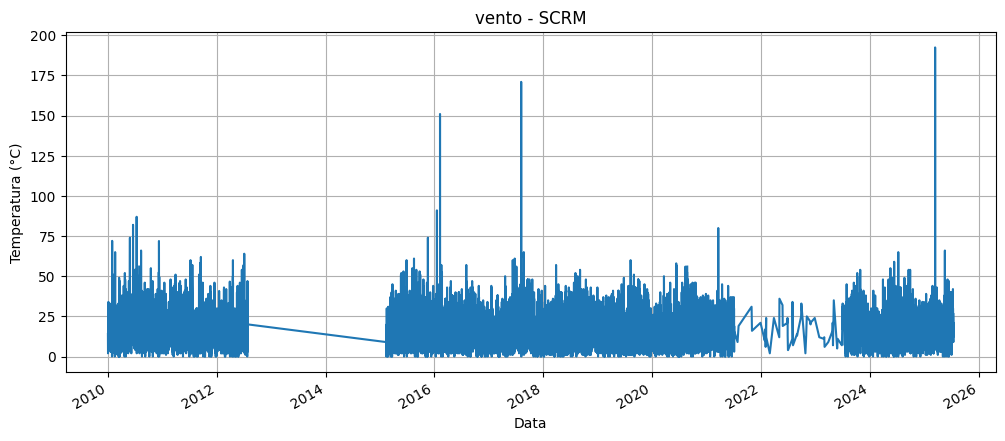

In [ ]:
import matplotlib.pyplot as plt

df['wind_knots'].plot(figsize=(12, 5), title='vento - SCRM')
plt.ylabel('Temperatura (°C)')
plt.xlabel('Data')
plt.grid(True)
plt.show()


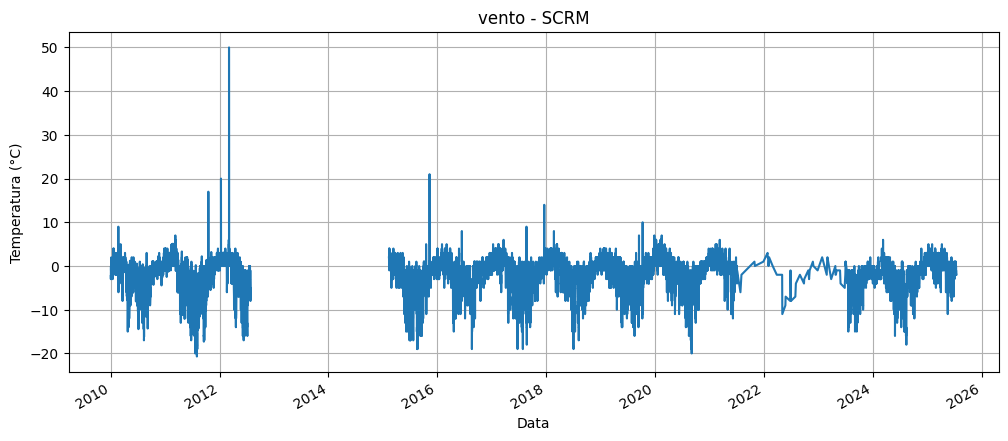

In [ ]:
import matplotlib.pyplot as plt

df['tmpc'].plot(figsize=(12, 5), title='vento - SCRM')
plt.ylabel('Temperatura (°C)')
plt.xlabel('Data')
plt.grid(True)
plt.show()

In [ ]:
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)


KeyError: 'wind_knots'

In [ ]:



# Garante que o índice está em datetime
df.index = pd.to_datetime(df.index)

# Filtra apenas dados de 2024
df_2024 = df.loc['2024-07']

# Pega os 100 maiores valores de wind_knots em 2024
top_5_wind_2024 = df_2024['wind_knots'].nlargest(50)

# Imprime em ordem cronológica
print(df_2024.loc[top_5_wind_2024.index][['wind_knots']].sort_index())


                     wind_knots
time                           
2024-07-05 21:00:00        33.0
2024-07-08 00:00:00        43.0
2024-07-08 03:00:00        33.0
2024-07-08 06:00:00        36.0
2024-07-08 09:00:00        36.0
2024-07-09 22:00:00        42.0
2024-07-09 23:00:00        46.0
2024-07-10 00:00:00        49.0
2024-07-10 03:00:00        60.0
2024-07-10 06:00:00        65.0
2024-07-10 09:00:00        55.0
2024-07-10 12:00:00        49.0
2024-07-10 13:00:00        47.0
2024-07-10 14:00:00        42.0
2024-07-10 15:00:00        40.0
2024-07-10 16:00:00        38.0
2024-07-10 17:00:00        39.0
2024-07-10 18:00:00        36.0
2024-07-10 19:00:00        36.0
2024-07-10 20:00:00        32.0
2024-07-12 09:00:00        35.0
2024-07-12 18:00:00        32.0
2024-07-12 19:00:00        35.0
2024-07-12 21:00:00        34.0
2024-07-14 18:00:00        37.0
2024-07-14 19:00:00        35.0
2024-07-14 21:00:00        33.0
2024-07-15 00:00:00        33.0
2024-07-21 06:00:00        37.0
2024-07-

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving metar_frei_2015_2025-novoteste.csv to metar_frei_2015_2025-novoteste.csv


In [ ]:
import pandas as pd

# Carrega o CSV enviado pela usuária
csv_path = "/content/metar_frei_2015_2025-novoteste.csv"
df = pd.read_csv(csv_path)

df.head()


,time,temp,dwpt,rhum,prcp,snow,wdir,wspd,wpgt,pres,tsun,coco
0,2015-01-01 00:00:00,-0.4,-2.8,88.0,NaN,NaN,250.0,25.9,NaN,1011.8,NaN,NaN
1,2015-01-01 06:00:00,-0.4,-3.6,84.0,NaN,NaN,260.0,18.4,NaN,1011.2,NaN,NaN
2,2015-01-01 12:00:00,-0.1,-3.7,82.0,NaN,NaN,260.0,14.8,NaN,1010.6,NaN,NaN
3,2015-01-01 18:00:00,0.8,-3.2,80.0,NaN,NaN,260.0,14.8,NaN,1010.1,NaN,NaN
4,2015-01-02 00:00:00,0.5,-4.9,73.0,NaN,NaN,180.0,3.6,NaN,1009.3,NaN,NaN


In [ ]:

    # Converter velocidade do vento de km/h para nós
df['wspd_knots'] = (df['wspd'] / 1.852).round(2)
df['wpgt_knots'] = (df['wpgt'] / 1.852).round(2)

In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
temp,87849.0,-1.862686,3.593566,-21.90,-3.00,-1.00,0.40,8.00
dwpt,87576.0,-3.850307,4.685299,-27.10,-6.20,-2.50,-0.40,6.00
rhum,87576.0,90.049808,9.393997,0.00,85.00,93.00,99.00,100.00
prcp,38946.0,0.146195,0.324564,0.00,0.00,0.00,0.10,6.00
snow,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wdir,87332.0,216.009069,109.563746,0.00,110.00,260.00,300.00,360.00
wspd,87729.0,34.584963,21.939043,0.00,20.50,31.70,43.60,249.50
wpgt,71.0,46.225352,14.031798,21.00,35.50,45.00,53.00,81.00
pres,56032.0,989.693789,12.522183,935.80,981.70,989.50,998.00,1030.10
tsun,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)

In [ ]:
# Garante que o índice está em datetime
df.index = pd.to_datetime(df.index)

# Filtra apenas dados de 2024
df_2024 = df.loc['2024-08']

# Pega os 100 maiores valores de wind_knots em 2024
top_5_wind_2024 = df_2024['wspd_knots'].nlargest(50)

# Imprime em ordem cronológica
print(df_2024.loc[top_5_wind_2024.index][['wspd_knots']].sort_index())

                     wspd_knots
time                           
2024-08-01 00:00:00       65.33
2024-08-01 23:00:00       75.81
2024-08-02 07:00:00       94.06
2024-08-02 08:00:00       87.85
2024-08-02 10:00:00       69.60
2024-08-03 18:00:00       67.44
2024-08-06 07:00:00       82.99
2024-08-07 16:00:00       99.51
2024-08-07 17:00:00       99.14
2024-08-09 01:00:00       86.50
2024-08-09 04:00:00      108.26
2024-08-10 19:00:00       68.25
2024-08-11 11:00:00      105.35
2024-08-13 05:00:00       89.42
2024-08-13 08:00:00       95.25
2024-08-13 17:00:00       65.71
2024-08-15 07:00:00       65.71
2024-08-15 11:00:00      103.62
2024-08-15 23:00:00       70.36
2024-08-16 02:00:00       70.36
2024-08-16 05:00:00       75.22
2024-08-16 07:00:00       74.84
2024-08-16 13:00:00       71.92
2024-08-16 14:00:00       65.50
2024-08-18 13:00:00       74.08
2024-08-18 23:00:00       68.63
2024-08-19 15:00:00       70.57
2024-08-20 03:00:00      125.97
2024-08-21 09:00:00       72.30
2024-08-